In [ ]:
# 13 raw sensors, data chronologically ordered, no engineered features, missing values handled in next code block

import pandas as pd

df = pd.read_parquet("../data/interim/data_sorted.parquet")

print("="*80)
print("Shape")
print(df.shape)

print("\n" + "="*80)
print("Columns")
print(df.columns.tolist())

print("\n" + "="*80)
print("Missing values (>0)")
print(df.isna().sum()[df.isna().sum()>0])

print("\n" + "="*80)
print("Head")
display(df.head())

print("\n" + "="*80)
print("Engineered columns")

engineered = [
    c for c in df.columns
    if any(k in c.lower() for k in [
        "lag",
        "std",
        "mean",
        "rolling",
        "roc",
        "diff",
        "ema",
        "momentum",
        "slope"
    ])
]

print(engineered)

print(f"\nTotal engineered columns: {len(engineered)}")

Shape
(1737585, 14)

Columns
['TimeStamp', '02FI_1000.PV', '03FIC_1085.PV', '03FI_3418.PV', '03LIC_1094.PV', '03PIC_1104.PV', '03TIC_1009.PV', '03TIC_1092.PV', '03TI_1002.PV', '03TI_1005.PV', '03TI_1081.PV', '03TI_1102.PV', '03TI_1108.PV', '03TI_1404.PV']

Missing values (>0)
02FI_1000.PV      667
03FIC_1085.PV     262
03FI_3418.PV        8
03LIC_1094.PV       3
03PIC_1104.PV       7
03TIC_1009.PV       3
03TIC_1092.PV       3
03TI_1002.PV     3040
03TI_1005.PV        4
03TI_1081.PV        4
03TI_1102.PV        4
03TI_1108.PV        7
03TI_1404.PV        8
dtype: int64

Head


,TimeStamp,02FI_1000.PV,03FIC_1085.PV,03FI_3418.PV,03LIC_1094.PV,03PIC_1104.PV,03TIC_1009.PV,03TIC_1092.PV,03TI_1002.PV,03TI_1005.PV,03TI_1081.PV,03TI_1102.PV,03TI_1108.PV,03TI_1404.PV
0,2022-01-03 22:45:00,6.645525,216.82233,30.962135,52.072630,25.146055,35.456966,4.624359,45.199110,42.732693,-36.141970,NaN,31.587097,36.090870
1,2022-01-03 22:46:00,6.682778,210.55800,32.483753,54.947033,25.226107,35.332653,4.643196,45.199110,42.401283,-36.198616,10.000004,31.564457,36.251778
2,2022-01-03 22:47:00,6.713386,212.94440,31.975134,55.953170,25.315577,35.016205,4.605526,45.199110,42.600132,-36.283580,9.962143,31.587097,36.280174
3,2022-01-03 22:48:00,6.706837,213.07224,32.305733,55.358322,25.400337,35.389156,4.793884,45.199110,42.495970,-36.297745,9.858025,31.598423,36.176056
4,2022-01-03 22:49:00,6.670256,214.64897,31.852217,56.762740,25.452137,35.287450,4.793884,45.227604,42.401283,-36.241100,9.734978,31.598423,36.251778



Engineered columns
[]

Total engineered columns: 0


In [12]:
#handling missing values - ffill()

# =====================================================
# HANDLE MISSING VALUES
# =====================================================

# Forward fill missing values
df = df.ffill()

# Remove the first row (only remaining NaN after ffill)
df = df.iloc[1:].reset_index(drop=True)

# Verify
print(df.isna().sum()[df.isna().sum() > 0])

# Freeze the cleaned master dataset
master_df = df.copy()

print(master_df.shape)

Series([], dtype: int64)
(1737584, 14)


Load dataset
      ↓
Forward fill
      ↓
Remove first row
      ↓
Verify
      ↓
Freeze master_df

In [13]:
# =====================================================
# PROJECT CONSTANTS
# =====================================================

TARGET_SENSOR = "03TIC_1009.PV"

LOOKBACK = 60

FORECAST_HORIZON = 15

ALARM_THRESHOLD = 30.5


In [14]:
#target generation

# =====================================================
# TARGET GENERATION
# =====================================================

feature_df = master_df.copy()

feature_df["target_min_next_15"] = (

    feature_df[TARGET_SENSOR]

    .shift(-1)

    .rolling(
        FORECAST_HORIZON,
        min_periods=FORECAST_HORIZON
    )

    .min()

    .shift(-(FORECAST_HORIZON - 1))

)

In [15]:
print(feature_df.shape)

feature_df[
    [
        "TimeStamp",
        TARGET_SENSOR,
        "target_min_next_15"
    ]
].head(20)

(1737584, 15)


,TimeStamp,03TIC_1009.PV,target_min_next_15
0,2022-01-03 22:46:00,35.332653,35.016205
1,2022-01-03 22:47:00,35.016205,35.287450
2,2022-01-03 22:48:00,35.389156,35.287450
3,2022-01-03 22:49:00,35.287450,35.423065
4,2022-01-03 22:50:00,35.423065,35.468270
5,2022-01-03 22:51:00,35.875122,35.468270
6,2022-01-03 22:52:00,35.468270,35.671696
7,2022-01-03 22:53:00,35.671696,35.762110
8,2022-01-03 22:54:00,35.762110,35.796017
9,2022-01-03 22:55:00,35.796017,35.886425


In [16]:
#mathematically verify

idx = 1000

future = feature_df.loc[
    idx+1:idx+FORECAST_HORIZON,
    TARGET_SENSOR
]

print("Current")

print(feature_df.loc[idx, TARGET_SENSOR])

print()

print("Future values")

print(future.values)

print()

print("Expected minimum")

print(future.min())

print()

print("Stored target")

print(
    feature_df.loc[
        idx,
        "target_min_next_15"
    ]
)

Current
35.773415

Future values
[36.135063 36.541912 36.65493  36.643627 37.45734  37.592957 37.005276
 37.208702 37.502544 36.982677 36.914867 37.106995 36.89227  36.880955
 37.24261 ]

Expected minimum
36.135063

Stored target
36.135063


In [17]:
feature_df.tail(20)[
    [
        "TimeStamp",
        TARGET_SENSOR,
        "target_min_next_15"
    ]
]

,TimeStamp,03TIC_1009.PV,target_min_next_15
1737564,2025-06-23 20:25:00,48.340714,47.58351
1737565,2025-06-23 20:26:00,48.318115,47.58351
1737566,2025-06-23 20:27:00,48.205093,47.58351
1737567,2025-06-23 20:28:00,48.193794,47.58351
1737568,2025-06-23 20:29:00,48.092080,47.58351
1737569,2025-06-23 20:30:00,47.979065,NaN
1737570,2025-06-23 20:31:00,47.798250,NaN
1737571,2025-06-23 20:32:00,47.775642,NaN
1737572,2025-06-23 20:33:00,47.673927,NaN
1737573,2025-06-23 20:34:00,47.696526,NaN


In [18]:
feature_df = feature_df.dropna(
    subset=["target_min_next_15"]
).reset_index(drop=True)

print(feature_df.shape)

(1737569, 15)


TEMPORAL FEATURES:
 Lag Features
 Rolling Mean
 Rolling Std
 Rate of Change (ROC)

TREND FEATURES:
 EMA
 Rolling Slope
 Momentum

In [19]:
# consensos sensors from previous experiments

# =====================================================
# CONSENSUS SENSORS
# =====================================================

CONSENSUS_SENSORS = [

    "03TIC_1009.PV",
    "03TI_1108.PV",
    "03TI_1005.PV",
    "03TI_1404.PV",
    "03TIC_1092.PV",
    "03TI_1102.PV",
    "03TI_1002.PV",
    "03FIC_1085.PV"

]

print(f"Consensus Sensors: {len(CONSENSUS_SENSORS)}")

CONSENSUS_SENSORS

Consensus Sensors: 8


['03TIC_1009.PV',
 '03TI_1108.PV',
 '03TI_1005.PV',
 '03TI_1404.PV',
 '03TIC_1092.PV',
 '03TI_1102.PV',
 '03TI_1002.PV',
 '03FIC_1085.PV']

In [20]:
engineered_df = feature_df.copy()

print(engineered_df.shape)

(1737569, 15)


In [ ]:
# =====================================================
# LAG FEATURES
# =====================================================

LAGS = [1, 5, 10, 15]

for sensor in CONSENSUS_SENSORS:

    for lag in LAGS:

        engineered_df[
            f"{sensor}_lag_{lag}"
        ] = engineered_df[sensor].shift(lag)

print(engineered_df.shape)


# using shorter lags to represent short-term dynamics since transformers have context from a lookback of 60 mins 

(1737569, 47)


In [22]:
# =====================================================
# ROLLING STANDARD DEVIATION
# =====================================================

STD_WINDOWS = [5, 15, 30]

for sensor in CONSENSUS_SENSORS:

    for window in STD_WINDOWS:

        engineered_df[
            f"{sensor}_std_{window}"
        ] = (

            engineered_df[sensor]

            .rolling(
                window=window,
                min_periods=window
            )

            .std()

        )

print(engineered_df.shape)

(1737569, 71)


ROLLING STD FEATURES
-captures process variability
-Window sizes = [5,15,30] = 5 captures immediate fluctuations, 15 captures fluctuations near horizon, 30 captures medium term process variability

In [23]:
std_cols = [

    c

    for c in engineered_df.columns

    if "_std_" in c

]

print(f"Rolling Std Features: {len(std_cols)}")

print(std_cols[:10])

Rolling Std Features: 24
['03TIC_1009.PV_std_5', '03TIC_1009.PV_std_15', '03TIC_1009.PV_std_30', '03TI_1108.PV_std_5', '03TI_1108.PV_std_15', '03TI_1108.PV_std_30', '03TI_1005.PV_std_5', '03TI_1005.PV_std_15', '03TI_1005.PV_std_30', '03TI_1404.PV_std_5']


Uptil now, 47 + 24 = 71 features

In [24]:
# =====================================================
# RATE OF CHANGE (ROC)
# =====================================================

ROC_WINDOWS = [5, 15]

for sensor in CONSENSUS_SENSORS:

    for window in ROC_WINDOWS:

        engineered_df[
            f"{sensor}_roc_{window}"
        ] = (

            engineered_df[sensor]

            - engineered_df[sensor].shift(window)

        )

In [25]:
roc_cols = [

    c

    for c in engineered_df.columns

    if "_roc_" in c

]

print(f"ROC Features: {len(roc_cols)}")

print(roc_cols[:10])

print(engineered_df.shape)

ROC Features: 16
['03TIC_1009.PV_roc_5', '03TIC_1009.PV_roc_15', '03TI_1108.PV_roc_5', '03TI_1108.PV_roc_15', '03TI_1005.PV_roc_5', '03TI_1005.PV_roc_15', '03TI_1404.PV_roc_5', '03TI_1404.PV_roc_15', '03TIC_1092.PV_roc_5', '03TIC_1092.PV_roc_15']
(1737569, 87)


87 Columns now

----
Distance Correlation with 2 - stage filtering:
    1. Feature -> Target: keep features with meaningful non-linear association to target_min_next_15

    2. Feature -> Feature: remove redundant features that essentially carry the same information.

This two-stage filtering should leave us with a much cleaner set of inputs before retraining the Transformer before we move to check if we even require additional features such as EMA, momentum, slopes, etc.

----

What changes from before:

Pearson correlation only measures linear relationships between a feature and the target. Industrial process variables often exhibit nonlinear dependencies, especially near operating limits and alarm conditions. Distance Correlation captures both linear and nonlinear associations, making it more appropriate for selecting engineered features in this forecasting problem.

----

'dcor' is an open-source Python Package that computes distance correlation and energy statistics to measure dependencies between random vectors.


----

1,737,569 rows
        │
        ▼
Random sample (100k–200k rows)
        │
        ▼
Distance Correlation
        │
        ▼
Rank engineered features
        │
        ▼
Keep top candidates
        │
        ▼
Remove redundancy
        │
        ▼
Train Transformer on full dataset

Distance Correlation was computed on a large, randomly sampled subset of 100,000 observations to reduce computational cost while preserving representative feature rankings. The selected features were subsequently used to train the Transformer on the complete dataset.

ROC tells how fast the process is changing

In [29]:

import numpy as np
import pandas as pd

In [30]:
import dcor
print("dcor loaded")

dcor loaded


In [31]:
# =====================================================
# CREATE SAMPLE FOR FEATURE SELECTION
# =====================================================

RANDOM_STATE = 42

SAMPLE_SIZE = 100_000

sample_df = (

    engineered_df

    .sample(
        n=SAMPLE_SIZE,
        random_state=RANDOM_STATE
    )

    .reset_index(drop=True)

)

print(sample_df.shape)

(100000, 87)


In [32]:
print("Original Target Statistics")

print(engineered_df["target_min_next_15"].describe())

print()

print("Sample Target Statistics")

print(sample_df["target_min_next_15"].describe())

Original Target Statistics
count    1.737569e+06
mean     4.185207e+01
std      4.522023e+00
min     -1.989793e+01
25%      3.919778e+01
50%      4.129986e+01
75%      4.385401e+01
max      5.975526e+01
Name: target_min_next_15, dtype: float64

Sample Target Statistics
count    100000.000000
mean         41.842048
std           4.522766
min         -19.897932
25%          39.186470
50%          41.299860
75%          43.842710
max          58.828530
Name: target_min_next_15, dtype: float64


In [33]:
sample_df = sample_df.dropna().reset_index(drop=True)

print(sample_df.shape)

print(sample_df.isna().sum().sum())

(100000, 87)
0


In [34]:
TARGET = "target_min_next_15"

feature_columns = [

    c

    for c in sample_df.columns

    if c not in [

        "TimeStamp",

        TARGET

    ]

]

print(f"Number of Features: {len(feature_columns)}")

Number of Features: 85


stratified sampling over random sampling for target distribution

In [ ]:
# =====================================================
# CREATE SAMPLE FOR FEATURE SELECTION
# =====================================================

# random sampling

RANDOM_STATE = 42

SAMPLE_SIZE = 100_000

sample_df = (

    engineered_df

    .sample(
        n=SAMPLE_SIZE,
        random_state=RANDOM_STATE
    )

    .reset_index(drop=True)

)

print(sample_df.shape)

(100000, 87)


In [36]:
sample_df = (

    sample_df

    .dropna()

    .reset_index(drop=True)

)

print(sample_df.shape)

print("Remaining NaNs:", sample_df.isna().sum().sum())

(100000, 87)
Remaining NaNs: 0


In [37]:
print("Original Dataset")

print(engineered_df["target_min_next_15"].describe())

print()

print("Sample Dataset")

print(sample_df["target_min_next_15"].describe())

Original Dataset
count    1.737569e+06
mean     4.185207e+01
std      4.522023e+00
min     -1.989793e+01
25%      3.919778e+01
50%      4.129986e+01
75%      4.385401e+01
max      5.975526e+01
Name: target_min_next_15, dtype: float64

Sample Dataset
count    100000.000000
mean         41.842048
std           4.522766
min         -19.897932
25%          39.186470
50%          41.299860
75%          43.842710
max          58.828530
Name: target_min_next_15, dtype: float64


In [38]:
TARGET = "target_min_next_15"

feature_columns = [

    c

    for c in sample_df.columns

    if c not in [

        "TimeStamp",

        TARGET

    ]

]

print("Total Features:", len(feature_columns))

Total Features: 85


In [40]:

from tqdm.auto import tqdm

distance_corr = {}

for feature in tqdm(feature_columns):

    distance_corr[feature] = dcor.distance_correlation(

        sample_df[feature].values,

        sample_df[TARGET].values

    )

  0%|          | 0/85 [00:00<?, ?it/s]

In [41]:
distance_corr_df = (

    pd.Series(distance_corr)

    .sort_values(
        ascending=False
    )

    .reset_index()

)

distance_corr_df.columns = [

    "Feature",

    "DistanceCorrelation"

]

distance_corr_df.head(30)

,Feature,DistanceCorrelation
0,03TIC_1009.PV,0.985087
1,03TIC_1009.PV_lag_1,0.984073
2,03TIC_1009.PV_lag_5,0.979377
3,03TIC_1009.PV_lag_10,0.973747
4,03TIC_1009.PV_lag_15,0.967956
5,03TI_1108.PV,0.909898
6,03TI_1108.PV_lag_1,0.908840
7,03TI_1108.PV_lag_5,0.904502
8,03TI_1108.PV_lag_10,0.899193
9,03TI_1108.PV_lag_15,0.894018


In [42]:
distance_corr_df.to_csv(

    "distance_correlation_scores.csv",

    index=False

)

print("Saved.")

Saved.


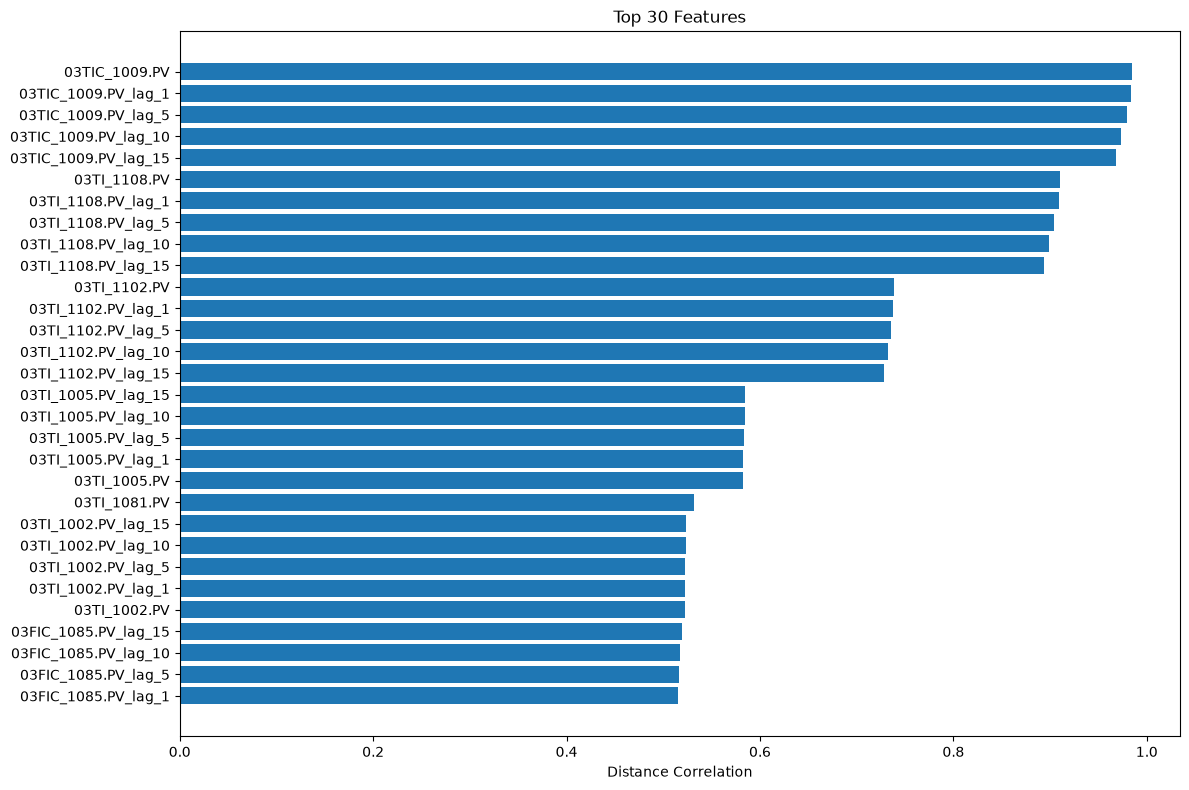

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plt.barh(

    distance_corr_df["Feature"][:30][::-1],

    distance_corr_df["DistanceCorrelation"][:30][::-1]

)

plt.xlabel("Distance Correlation")

plt.title("Top 30 Features")

plt.tight_layout()

plt.show()

In [47]:
distance_corr_df[
    distance_corr_df["Feature"].str.contains("_std_")
].head(20)



,Feature,DistanceCorrelation
31,03TIC_1009.PV_std_5,0.317500
42,03TI_1102.PV_std_30,0.275731
44,03TI_1108.PV_std_30,0.263486
45,03TIC_1009.PV_std_15,0.240811
48,03TI_1102.PV_std_15,0.228014
49,03TI_1108.PV_std_15,0.220442
50,03TI_1005.PV_std_15,0.187637
51,03TI_1005.PV_std_5,0.183195
52,03TI_1102.PV_std_5,0.176154
53,03TI_1005.PV_std_30,0.174681


In [46]:
distance_corr_df[
    distance_corr_df["Feature"].str.contains("_roc_")
].head(20)

,Feature,DistanceCorrelation
54,03TI_1108.PV_roc_15,0.173582
58,03TI_1102.PV_roc_15,0.140320
59,03TI_1108.PV_roc_5,0.139766
66,03TI_1102.PV_roc_5,0.098395
69,03TIC_1009.PV_roc_5,0.084208
72,03TI_1005.PV_roc_15,0.063548
74,03TI_1005.PV_roc_5,0.059095
75,03TIC_1092.PV_roc_15,0.058286
76,03TIC_1009.PV_roc_15,0.057012
77,03FIC_1085.PV_roc_5,0.054930


CONCLUSIONS

Very strong features
    03TIC_1009
    03TIC_1009_lag_*
    03TI_1108
    03TI_1108_lag_*
    03TI_1102
    03TI_1102_lag_*
    03TI_1005
    03TI_1005_lag_*
Medium features
    Rolling Std
    0.18–0.32
Weak features
    ROC
    0.03–0.17

REDUNDANCY REMOVAL

85 features
      ↓
Feature-feature correlation
      ↓
Keep representative features
      ↓
≈ 30–40 features

In [48]:
# =====================================================
# KEEP FEATURES WITH SUFFICIENT DISTANCE CORRELATION
# =====================================================

DCOR_THRESHOLD = 0.15

selected_features = distance_corr_df.loc[
    distance_corr_df["DistanceCorrelation"] >= DCOR_THRESHOLD,
    "Feature"
].tolist()

print(f"Selected Features: {len(selected_features)}")

selected_features[:20]

Selected Features: 58


['03TIC_1009.PV',
 '03TIC_1009.PV_lag_1',
 '03TIC_1009.PV_lag_5',
 '03TIC_1009.PV_lag_10',
 '03TIC_1009.PV_lag_15',
 '03TI_1108.PV',
 '03TI_1108.PV_lag_1',
 '03TI_1108.PV_lag_5',
 '03TI_1108.PV_lag_10',
 '03TI_1108.PV_lag_15',
 '03TI_1102.PV',
 '03TI_1102.PV_lag_1',
 '03TI_1102.PV_lag_5',
 '03TI_1102.PV_lag_10',
 '03TI_1102.PV_lag_15',
 '03TI_1005.PV_lag_15',
 '03TI_1005.PV_lag_10',
 '03TI_1005.PV_lag_5',
 '03TI_1005.PV_lag_1',
 '03TI_1005.PV']

03TI_1108.PV

↓

03TI_1108.PV_lag_1

↓

03TI_1108.PV_std_5

↓

03TI_1108.PV_roc_15


--------------------------

03TI_1108.PV

↓

03FIC_1085.PV_std_30

In [49]:
from collections import defaultdict

feature_groups = defaultdict(list)

for feature in selected_features:

    matched = False

    for sensor in CONSENSUS_SENSORS:

        if feature.startswith(sensor):

            feature_groups[sensor].append(feature)

            matched = True

            break

    if not matched:

        feature_groups["OTHER"].append(feature)

In [50]:
for sensor, feats in feature_groups.items():

    print("="*70)

    print(sensor)

    print()

    for f in feats:

        print(f)

03TIC_1009.PV

03TIC_1009.PV
03TIC_1009.PV_lag_1
03TIC_1009.PV_lag_5
03TIC_1009.PV_lag_10
03TIC_1009.PV_lag_15
03TIC_1009.PV_std_5
03TIC_1009.PV_std_15
03TIC_1009.PV_std_30
03TI_1108.PV

03TI_1108.PV
03TI_1108.PV_lag_1
03TI_1108.PV_lag_5
03TI_1108.PV_lag_10
03TI_1108.PV_lag_15
03TI_1108.PV_std_30
03TI_1108.PV_std_15
03TI_1108.PV_roc_15
03TI_1108.PV_std_5
03TI_1102.PV

03TI_1102.PV
03TI_1102.PV_lag_1
03TI_1102.PV_lag_5
03TI_1102.PV_lag_10
03TI_1102.PV_lag_15
03TI_1102.PV_std_30
03TI_1102.PV_std_15
03TI_1102.PV_std_5
03TI_1005.PV

03TI_1005.PV_lag_15
03TI_1005.PV_lag_10
03TI_1005.PV_lag_5
03TI_1005.PV_lag_1
03TI_1005.PV
03TI_1005.PV_std_15
03TI_1005.PV_std_5
03TI_1005.PV_std_30
OTHER

03TI_1081.PV
02FI_1000.PV
03FI_3418.PV
03PIC_1104.PV
03TI_1002.PV

03TI_1002.PV_lag_15
03TI_1002.PV_lag_10
03TI_1002.PV_lag_5
03TI_1002.PV_lag_1
03TI_1002.PV
03FIC_1085.PV

03FIC_1085.PV_lag_15
03FIC_1085.PV_lag_10
03FIC_1085.PV_lag_5
03FIC_1085.PV_lag_1
03FIC_1085.PV
03TIC_1092.PV

03TIC_1092.PV_lag_15
03T

In [51]:
correlation_matrices = {}

for sensor, feats in feature_groups.items():

    if len(feats) < 2:

        continue

    corr = engineered_df[feats].corr().abs()

    correlation_matrices[sensor] = corr

In [52]:
correlation_matrices["03TIC_1009.PV"]

,03TIC_1009.PV,03TIC_1009.PV_lag_1,03TIC_1009.PV_lag_5,03TIC_1009.PV_lag_10,03TIC_1009.PV_lag_15,03TIC_1009.PV_std_5,03TIC_1009.PV_std_15,03TIC_1009.PV_std_30
03TIC_1009.PV,1.000000,0.994579,0.991315,0.986547,0.982258,0.261221,0.170499,0.071036
03TIC_1009.PV_lag_1,0.994579,1.000000,0.991911,0.987065,0.982906,0.261750,0.171167,0.071834
03TIC_1009.PV_lag_5,0.991315,0.991911,1.000000,0.991315,0.986547,0.264171,0.176171,0.076693
03TIC_1009.PV_lag_10,0.986547,0.987065,0.991315,1.000000,0.991315,0.266038,0.183460,0.084612
03TIC_1009.PV_lag_15,0.982258,0.982906,0.986547,0.991315,1.000000,0.267940,0.188800,0.093255
03TIC_1009.PV_std_5,0.261221,0.261750,0.264171,0.266038,0.267940,1.000000,0.743091,0.534376
03TIC_1009.PV_std_15,0.170499,0.171167,0.176171,0.183460,0.188800,0.743091,1.000000,0.788437
03TIC_1009.PV_std_30,0.071036,0.071834,0.076693,0.084612,0.093255,0.534376,0.788437,1.000000


In [53]:
CORR_THRESHOLD = 0.95

feature_scores = dict(
    zip(
        distance_corr_df["Feature"],
        distance_corr_df["DistanceCorrelation"]
    )
)

final_features = []

for sensor, feats in feature_groups.items():

    remaining = set(feats)

    corr = engineered_df[feats].corr().abs()

    for i in range(len(feats)):

        for j in range(i + 1, len(feats)):

            f1 = feats[i]

            f2 = feats[j]

            if (
                f1 in remaining
                and
                f2 in remaining
                and
                corr.loc[f1, f2] > CORR_THRESHOLD
            ):

                if feature_scores[f1] >= feature_scores[f2]:

                    remaining.remove(f2)

                else:

                    remaining.remove(f1)

    final_features.extend(sorted(remaining))

In [54]:
print("="*60)

print(f"Original Features : {len(feature_columns)}")

print(f"After DCOR        : {len(selected_features)}")

print(f"Final Features    : {len(final_features)}")

Original Features : 85
After DCOR        : 58
Final Features    : 27


In [55]:
# =====================================================
# SENSOR-WISE CORRELATION SUMMARY
# =====================================================

import numpy as np
import pandas as pd

summary = []

for sensor in CONSENSUS_SENSORS:

    cols = [

        c

        for c in selected_features

        if c.startswith(sensor)

    ]

    corr = engineered_df[cols].corr().abs()

    summary.append({

        "Sensor": sensor,

        "No_of_Features": len(cols),

        "Max_Correlation": corr.where(
            ~np.eye(len(corr), dtype=bool)
        ).max().max(),

        "Mean_Correlation": corr.where(
            ~np.eye(len(corr), dtype=bool)
        ).stack().mean()

    })

summary_df = pd.DataFrame(summary)

summary_df

,Sensor,No_of_Features,Max_Correlation,Mean_Correlation
0,03TIC_1009.PV,8,0.994579,0.520011
1,03TI_1108.PV,9,0.999927,0.424887
2,03TI_1005.PV,8,0.995487,0.474816
3,03TI_1404.PV,6,0.998586,0.724183
4,03TIC_1092.PV,5,0.998880,0.992196
5,03TI_1102.PV,8,0.999580,0.526404
6,03TI_1002.PV,5,0.999020,0.984163
7,03FIC_1085.PV,5,0.988733,0.924700


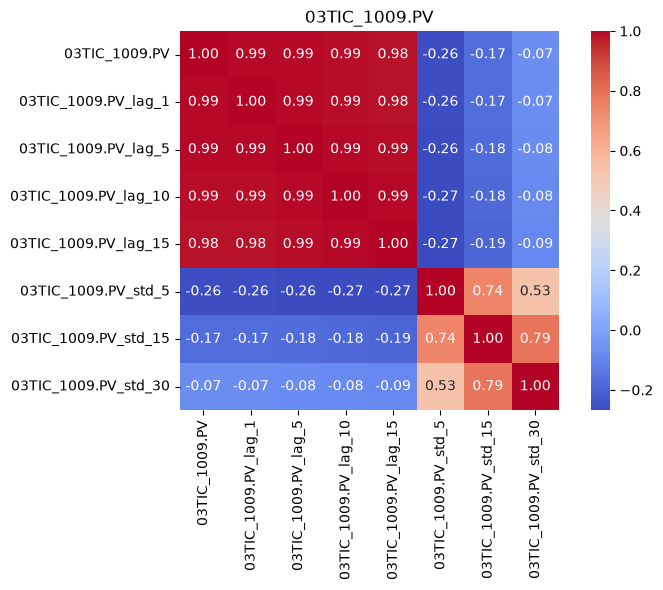

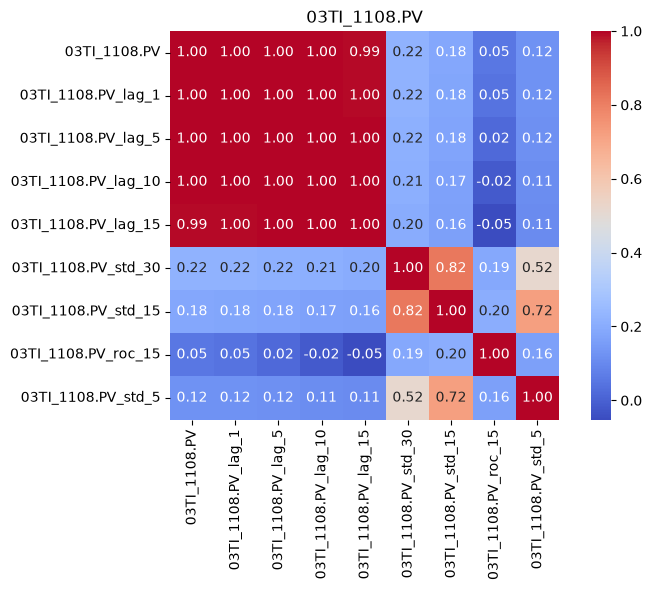

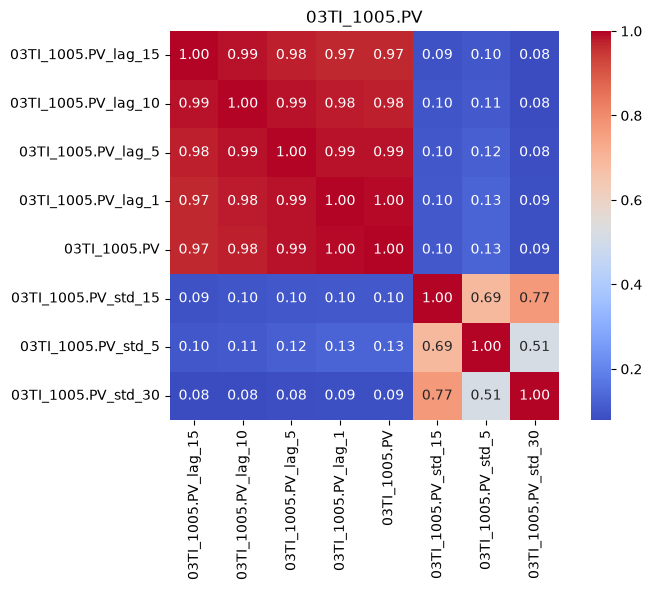

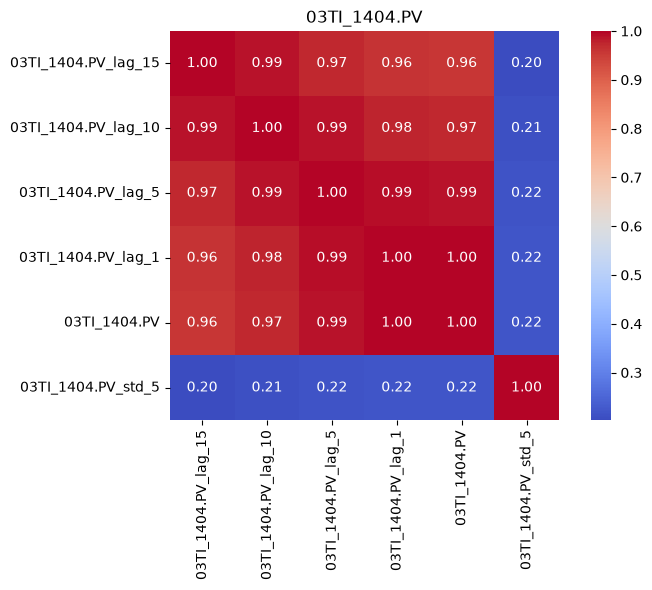

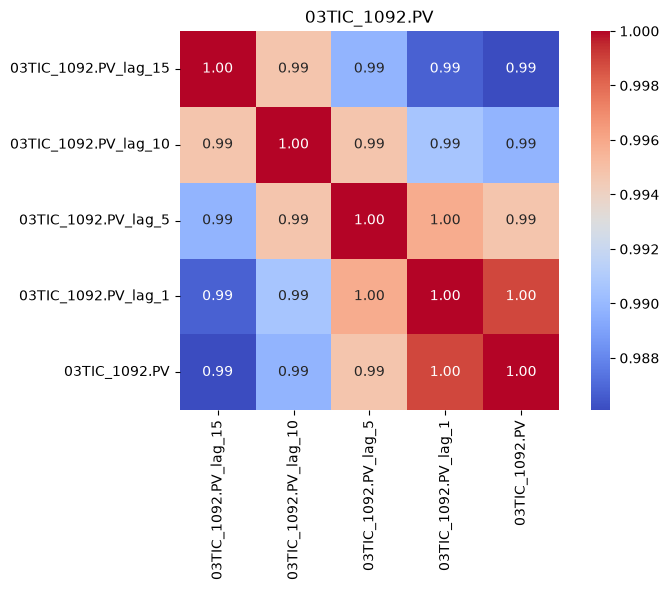

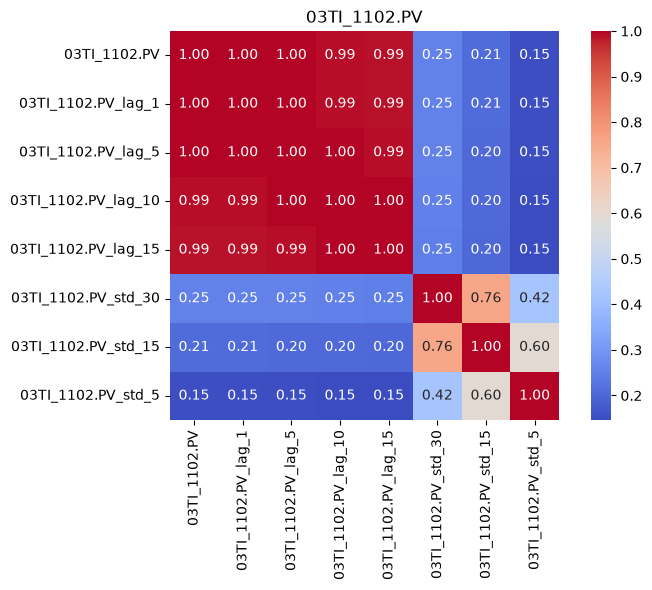

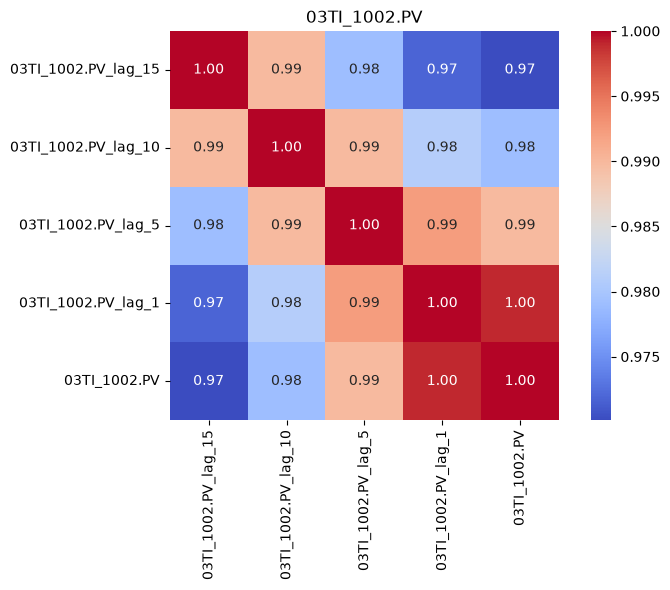

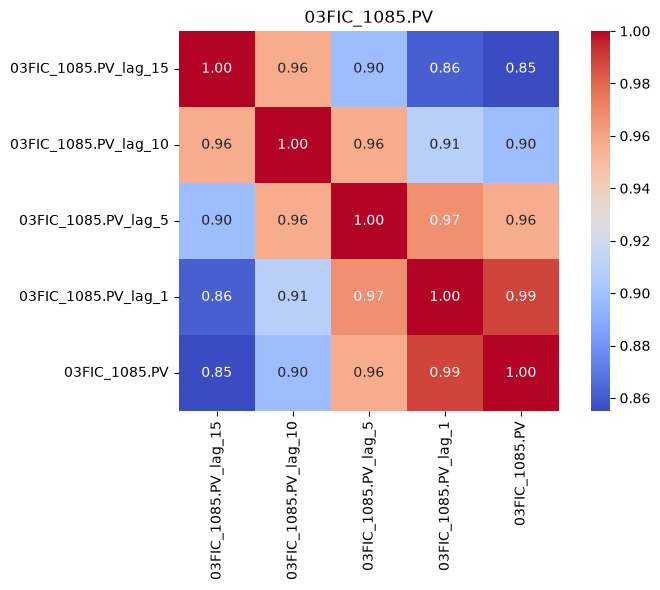

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

for sensor in CONSENSUS_SENSORS:

    cols = [

        c

        for c in selected_features

        if c.startswith(sensor)

    ]

    corr = engineered_df[cols].corr()

    plt.figure(figsize=(8,6))

    sns.heatmap(

        corr,

        annot=True,

        fmt=".2f",

        cmap="coolwarm",

        square=True

    )

    plt.title(sensor)

    plt.tight_layout()

    plt.show()

lag features are redundant, rolling std features are in ranges of 0.7 so they are measuring different variability scales, roc is weakly correlated to std and raw features but the redundancy is also low - so it is capturing something different , we keep roc and train transformers and then see its importance via SHAP

Raw

+

Lag15

+

All Std

+

All ROC

Reduces from 85 -> 56

In [57]:
# organzing feature groups before finalizing the final feature set

# =====================================================
# ORGANIZE FEATURES
# =====================================================

raw_features = []
lag_features = []
std_features = []
roc_features = []

for col in selected_features:

    if "_lag_" in col:
        lag_features.append(col)

    elif "_std_" in col:
        std_features.append(col)

    elif "_roc_" in col:
        roc_features.append(col)

    else:
        raw_features.append(col)

print("Raw :", len(raw_features))
print("Lag :", len(lag_features))
print("STD :", len(std_features))
print("ROC :", len(roc_features))

Raw : 12
Lag : 32
STD : 13
ROC : 1


In [58]:
for f in selected_features:
    print(f)

03TIC_1009.PV
03TIC_1009.PV_lag_1
03TIC_1009.PV_lag_5
03TIC_1009.PV_lag_10
03TIC_1009.PV_lag_15
03TI_1108.PV
03TI_1108.PV_lag_1
03TI_1108.PV_lag_5
03TI_1108.PV_lag_10
03TI_1108.PV_lag_15
03TI_1102.PV
03TI_1102.PV_lag_1
03TI_1102.PV_lag_5
03TI_1102.PV_lag_10
03TI_1102.PV_lag_15
03TI_1005.PV_lag_15
03TI_1005.PV_lag_10
03TI_1005.PV_lag_5
03TI_1005.PV_lag_1
03TI_1005.PV
03TI_1081.PV
03TI_1002.PV_lag_15
03TI_1002.PV_lag_10
03TI_1002.PV_lag_5
03TI_1002.PV_lag_1
03TI_1002.PV
03FIC_1085.PV_lag_15
03FIC_1085.PV_lag_10
03FIC_1085.PV_lag_5
03FIC_1085.PV_lag_1
03FIC_1085.PV
03TIC_1009.PV_std_5
03TIC_1092.PV_lag_15
03TIC_1092.PV_lag_10
03TIC_1092.PV_lag_5
03TIC_1092.PV_lag_1
03TIC_1092.PV
03TI_1404.PV_lag_15
03TI_1404.PV_lag_10
03TI_1404.PV_lag_5
03TI_1404.PV_lag_1
03TI_1404.PV
03TI_1102.PV_std_30
02FI_1000.PV
03TI_1108.PV_std_30
03TIC_1009.PV_std_15
03FI_3418.PV
03PIC_1104.PV
03TI_1102.PV_std_15
03TI_1108.PV_std_15
03TI_1005.PV_std_15
03TI_1005.PV_std_5
03TI_1102.PV_std_5
03TI_1005.PV_std_30
03TI_

In [ ]:
# Keep only Lag15

lag15_features = [

    f

    for f in lag_features

    if "_lag_15" in f

]

experiment_features = (

    raw_features

    + lag15_features

    + std_features

    + roc_features

)

print(len(experiment_features))

for f in experiment_features:
    print(f)

34
03TIC_1009.PV
03TI_1108.PV
03TI_1102.PV
03TI_1005.PV
03TI_1081.PV
03TI_1002.PV
03FIC_1085.PV
03TIC_1092.PV
03TI_1404.PV
02FI_1000.PV
03FI_3418.PV
03PIC_1104.PV
03TIC_1009.PV_lag_15
03TI_1108.PV_lag_15
03TI_1102.PV_lag_15
03TI_1005.PV_lag_15
03TI_1002.PV_lag_15
03FIC_1085.PV_lag_15
03TIC_1092.PV_lag_15
03TI_1404.PV_lag_15
03TIC_1009.PV_std_5
03TI_1102.PV_std_30
03TI_1108.PV_std_30
03TIC_1009.PV_std_15
03TI_1102.PV_std_15
03TI_1108.PV_std_15
03TI_1005.PV_std_15
03TI_1005.PV_std_5
03TI_1102.PV_std_5
03TI_1005.PV_std_30
03TI_1404.PV_std_5
03TIC_1009.PV_std_30
03TI_1108.PV_std_5
03TI_1108.PV_roc_15


In [60]:
import json

with open("transformer_34_features.json", "w") as f:
    json.dump(experiment_features, f, indent=4)

print(f"Saved {len(experiment_features)} features.")

Saved 34 features.


In [66]:
engineered_df = engineered_df.dropna().reset_index(drop=True)

engineered_df.to_parquet(
    "engineered_alarm_dataset.parquet",
    index=False
)

In [62]:
df_check = pd.read_parquet("engineered_alarm_dataset.parquet")

print(df_check.shape)

df_check.head()

(1737569, 88)


,TimeStamp,02FI_1000.PV,03FIC_1085.PV,03FI_3418.PV,03LIC_1094.PV,03PIC_1104.PV,03TIC_1009.PV,03TIC_1092.PV,03TI_1002.PV,03TI_1005.PV,...,03TI_1404.PV_roc_15,03TIC_1092.PV_roc_5,03TIC_1092.PV_roc_15,03TI_1102.PV_roc_5,03TI_1102.PV_roc_15,03TI_1002.PV_roc_5,03TI_1002.PV_roc_15,03FIC_1085.PV_roc_5,03FIC_1085.PV_roc_15,target_bin
0,2022-01-03 22:46:00,6.682778,210.55800,32.483753,54.947033,25.226107,35.332653,4.643196,45.199110,42.401283,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,2022-01-03 22:47:00,6.713386,212.94440,31.975134,55.953170,25.315577,35.016205,4.605526,45.199110,42.600132,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,2022-01-03 22:48:00,6.706837,213.07224,32.305733,55.358322,25.400337,35.389156,4.793884,45.199110,42.495970,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,2022-01-03 22:49:00,6.670256,214.64897,31.852217,56.762740,25.452137,35.287450,4.793884,45.227604,42.401283,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
4,2022-01-03 22:50:00,6.651906,216.01263,31.805593,55.463184,25.546316,35.423065,4.840977,45.208610,42.922073,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


In [ ]:
#saving later for SHAP analysis

distance_corr_df.to_csv(
    "distance_correlation_scores.csv",
    index=False
)

print("Distance Correlation scores saved.")

Distance Correlation scores saved.


In [64]:
# correlation metadata

metadata = {
    "dataset": "engineered_alarm_dataset",
    "total_features": 85,
    "selected_after_dcor": 58,
    "final_transformer_features": 34,
    "target": "target_min_next_15",
    "sampling": "100000 random samples",
    "distance_correlation_threshold": 0.15
}

with open("experiment_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

In [65]:
import json

with open("engineered_features_85.json", "w") as f:
    json.dump(feature_columns, f, indent=4)

print(f"Saved {len(feature_columns)} engineered features.")

Saved 85 engineered features.
